In [ ]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch

# 4bit pre quantized models we support for 4x faster downloading + no OOMs.
fourbit_models = [
    "unsloth/Llama-3.2-11B-Vision-Instruct-bnb-4bit", # Llama 3.2 vision support
    "unsloth/Llama-3.2-11B-Vision-bnb-4bit",
    "unsloth/Llama-3.2-90B-Vision-Instruct-bnb-4bit", # Can fit in a 80GB card!
    "unsloth/Llama-3.2-90B-Vision-bnb-4bit",

    "unsloth/Pixtral-12B-2409-bnb-4bit",              # Pixtral fits in 16GB!
    "unsloth/Pixtral-12B-Base-2409-bnb-4bit",         # Pixtral base model

    "unsloth/Qwen2-VL-2B-Instruct-bnb-4bit",          # Qwen2 VL support
    "unsloth/Qwen2-VL-7B-Instruct-bnb-4bit",
    "unsloth/Qwen2-VL-72B-Instruct-bnb-4bit",

    "unsloth/llava-v1.6-mistral-7b-hf-bnb-4bit",      # Any Llava variant works!
    "unsloth/llava-1.5-7b-hf-bnb-4bit",
] # More models at https://huggingface.co/unsloth

model, processor = FastVisionModel.from_pretrained(
    "unsloth/gemma-3-4b-pt",
    load_in_4bit = True, # Use 4bit to reduce memory use. False for 16bit LoRA.
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.6.6: Fast Gemma3 patching. Transformers: 4.52.4.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 7.5. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma3 won't work! Using float32.


model.safetensors:   0%|          | 0.00/4.38G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/210 [00:00<?, ?B/s]

processor_config.json:   0%|          | 0.00/70.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

We now add LoRA adapters for parameter efficient fine-tuning, allowing us to train only 1% of all model parameters efficiently.

**[NEW]** We also support fine-tuning only the vision component, only the language component, or both. Additionally, you can choose to fine-tune the attention modules, the MLP layers, or both!

In [ ]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True, # False if not finetuning vision layers
    finetune_language_layers   = True, # False if not finetuning language layers
    finetune_attention_modules = True, # False if not finetuning attention layers
    finetune_mlp_modules       = True, # False if not finetuning MLP layers

    r = 16,                           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 16,                  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,               # We support rank stabilized LoRA
    loftq_config = None,               # And LoftQ
    target_modules = "all-linear",    # Optional now! Can specify a list if needed
)

Unsloth: Making `base_model.model.model.vision_tower.vision_model` require gradients


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

base_dir = "/content/drive/MyDrive/ML_Group"
image_dir = os.path.join(base_dir, "images")
json_path = os.path.join(base_dir, "data.json")

print("Images folder exists:", os.path.exists(image_dir))
print("Data file exists:", os.path.exists(json_path))

files = sorted(os.listdir(image_dir))
print("Images count:", len(files))
print(files[:20])

Images folder exists: True
Data file exists: True
Images count: 193
['075148490-3b70efe8-1fb1-4f94-a0e2-c4f1e3a54a88.jpg', '6cd5f800-7114-11ed-9cb7-79d673630487.jpg', 'IMG_0552.jpg', 'IMG_0650.jpg', 'IMG_0926.jpg', 'IMG_0928.jpg', 'IMG_0929.jpg', 'IMG_0930.jpg', 'IMG_0931.jpg', 'IMG_0935.jpg', 'IMG_0949.jpg', 'IMG_0950.jpg', 'IMG_0951.jpg', 'IMG_6519.jpg', 'IMG_6523.jpg', 'IMG_6524.jpg', 'IMG_7101.jpg', 'Messenger_creation_0B8C14A3-18CF-4AD0-A06F-F9F4729D4C76.jpeg', 'Messenger_creation_0D1FBE36-5203-45FD-8A73-F44EF516A4B0.jpeg', 'Messenger_creation_0D268DF9-AB43-42A5-8DBC-B40C1735737C.jpeg']


In [4]:
import os
import re

def normalize_name(name):
    name = os.path.basename(name).lower()
    name = name.replace(" ", "")
    name = name.replace("_", "")
    name = name.replace("-", "")
    name = name.replace("(1)", "")
    name = re.sub(r"\.(jpg|jpeg|png|webp)$", "", name)
    return name

actual_files = os.listdir(image_dir)

file_lookup = {}
for fname in actual_files:
    key = normalize_name(fname)
    file_lookup[key] = fname

def resolve_image_path(relative_path):
    expected_name = os.path.basename(relative_path)

    # 1. Tikslus kelias
    exact_path = os.path.join(base_dir, relative_path)
    if os.path.exists(exact_path):
        return exact_path

    # 2. Bandome pagal normalizuotą vardą
    key = normalize_name(expected_name)
    if key in file_lookup:
        return os.path.join(image_dir, file_lookup[key])

    return None

In [5]:
import json

rows = []
missing = []

with open(json_path, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue

        item = json.loads(line)

        resolved_path = resolve_image_path(item["image"])

        if resolved_path is None:
            missing.append(item["image"])
            continue

        rows.append({
            "image_path": resolved_path,
            "original_image": item["image"],
            "caption_lt": item["caption_lt"]
        })

print("Valid rows:", len(rows))
print("Missing rows:", len(missing))

print("Missing examples:")
for x in missing[:20]:
    print(x)

print("First valid example:")
print(rows[0])

Valid rows: 193
Missing rows: 0
Missing examples:
First valid example:
{'image_path': '/content/drive/MyDrive/ML_Group/images/6cd5f800-7114-11ed-9cb7-79d673630487.jpg', 'original_image': 'images/6cd5f800-7114-11ed-9cb7-79d673630487.jpg', 'caption_lt': 'Nuotraukoje matomas Lietuvos kelias su kelio darbų zona ir laikinais eismo organizavimo ženklais. Matomi mėlyni krypties ženklai su baltomis rodyklėmis, nurodantys važiavimo kryptį per eismo juostas. Aiškaus įskaitomo teksto ant ženklų nėra.'}


In [6]:
from PIL import Image
from tqdm import tqdm

resized_dir = os.path.join(base_dir, "images_resized")
os.makedirs(resized_dir, exist_ok=True)

def resize_and_save_image(input_path, output_path, max_size=768):
    image = Image.open(input_path).convert("RGB")
    image.thumbnail((max_size, max_size))

    # Išsaugom kaip JPEG, kad būtų mažiau vietos
    image.save(output_path, "JPEG", quality=90)

clean_rows = []

for i, row in enumerate(tqdm(rows)):
    output_name = f"image_{i:05d}.jpg"
    output_path = os.path.join(resized_dir, output_name)

    if not os.path.exists(output_path):
        resize_and_save_image(row["image_path"], output_path, max_size=768)

    clean_rows.append({
        "image_path": output_path,
        "original_image": row["original_image"],
        "caption_lt": row["caption_lt"]
    })

print("Prepared resized images:", len(clean_rows))
print(clean_rows[0])

100%|██████████| 193/193 [00:41<00:00,  4.61it/s]

Prepared resized images: 193
{'image_path': '/content/drive/MyDrive/ML_Group/images_resized/image_00000.jpg', 'original_image': 'images/6cd5f800-7114-11ed-9cb7-79d673630487.jpg', 'caption_lt': 'Nuotraukoje matomas Lietuvos kelias su kelio darbų zona ir laikinais eismo organizavimo ženklais. Matomi mėlyni krypties ženklai su baltomis rodyklėmis, nurodantys važiavimo kryptį per eismo juostas. Aiškaus įskaitomo teksto ant ženklų nėra.'}


In [7]:
clean_json_path = os.path.join(base_dir, "data_clean_resized.jsonl")

with open(clean_json_path, "w", encoding="utf-8") as f:
    for row in clean_rows:
        item = {
            "image": row["image_path"],
            "original_image": row["original_image"],
            "caption_lt": row["caption_lt"]
        }
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("Saved:", clean_json_path)

Saved: /content/drive/MyDrive/ML_Group/data_clean_resized.jsonl


In [8]:
import json
from PIL import Image

clean_json_path = "/content/drive/MyDrive/ML_Group/data_clean_resized.jsonl"

dataset = []

with open(clean_json_path, "r", encoding="utf-8") as f:
    for line in f:
        item = json.loads(line)
        dataset.append(item)

print("Dataset size:", len(dataset))
print(dataset[0])

Dataset size: 193
{'image': '/content/drive/MyDrive/ML_Group/images_resized/image_00000.jpg', 'original_image': 'images/6cd5f800-7114-11ed-9cb7-79d673630487.jpg', 'caption_lt': 'Nuotraukoje matomas Lietuvos kelias su kelio darbų zona ir laikinais eismo organizavimo ženklais. Matomi mėlyni krypties ženklai su baltomis rodyklėmis, nurodantys važiavimo kryptį per eismo juostas. Aiškaus įskaitomo teksto ant ženklų nėra.'}


In [9]:
from PIL import Image

instruction = """
Aprašyk vaizde matomus kelio ženklus lietuviškai.
Trumpai paminėk bendrą aplinką, bet pagrindinį dėmesį skirk kelio ženklams, jų rodyklėms, simboliams, skaičiams, tekstui ir reikšmei.
Jei ženklas neaiškus arba tekstas neįskaitomas, nespėliok.
"""

def convert_to_conversation(sample):
    image = Image.open(sample["image"]).convert("RGB")

    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": instruction},
                {"type": "image", "image": image},
            ],
        },
        {
            "role": "assistant",
            "content": [
                {"type": "text", "text": sample["caption_lt"]}
            ],
        },
    ]

    return {
        "messages": conversation,
        "image_path": sample["image"],
        "caption_lt": sample["caption_lt"],
        "original_image": sample["original_image"],
    }

converted_dataset = [convert_to_conversation(sample) for sample in dataset]

print("Converted:", len(converted_dataset))
converted_dataset[0]["messages"]

Converted: 193


[{'role': 'user',
  'content': [{'type': 'text',
    'text': '\nAprašyk vaizde matomus kelio ženklus lietuviškai.\nTrumpai paminėk bendrą aplinką, bet pagrindinį dėmesį skirk kelio ženklams, jų rodyklėms, simboliams, skaičiams, tekstui ir reikšmei.\nJei ženklas neaiškus arba tekstas neįskaitomas, nespėliok.\n'},
   {'type': 'image', 'image': <PIL.Image.Image image mode=RGB size=768x455>}]},
 {'role': 'assistant',
  'content': [{'type': 'text',
    'text': 'Nuotraukoje matomas Lietuvos kelias su kelio darbų zona ir laikinais eismo organizavimo ženklais. Matomi mėlyni krypties ženklai su baltomis rodyklėmis, nurodantys važiavimo kryptį per eismo juostas. Aiškaus įskaitomo teksto ant ženklų nėra.'}]}]

In [10]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(
    converted_dataset,
    test_size=0.12,
    random_state=42
)

train_data, val_data = train_test_split(
    train_data,
    test_size=0.10,
    random_state=42
)

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

Train: 152
Validation: 17
Test: 24


IMAGE: /content/drive/MyDrive/ML_Group/images_resized/image_00126.jpg
ORIGINAL: images/PXL_20260521_153949479.jpg
CAPTION: Nuotraukoje pro šoninį langą matoma automobilių stovėjimo aikštelė prie žalio šlaito ir laiptų. Matomas mėlynas stovėjimo ženklas „P“ su papildomomis rodyklėmis. Aplink stovi keli lengvieji automobiliai ir baltas mikroautobusas.


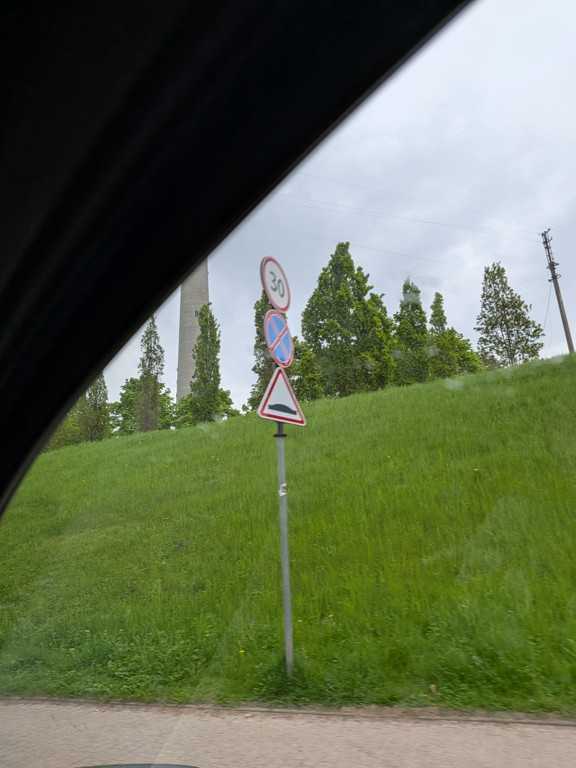

----------------------------------------------------------------------------------------------------
IMAGE: /content/drive/MyDrive/ML_Group/images_resized/image_00097.jpg
ORIGINAL: images/PXL_20260521_153647832.jpg
CAPTION: Nuotraukoje matoma gatvės atkarpa pro automobilio priekinį stiklą. Kairėje tolumoje matomas mėlynas eismo juostų krypties ženklas, rodantis važiavimo kryptis skirtingoms juostoms. Vaizdas užfiksuotas važiuojant per drėgną kelio dangą.


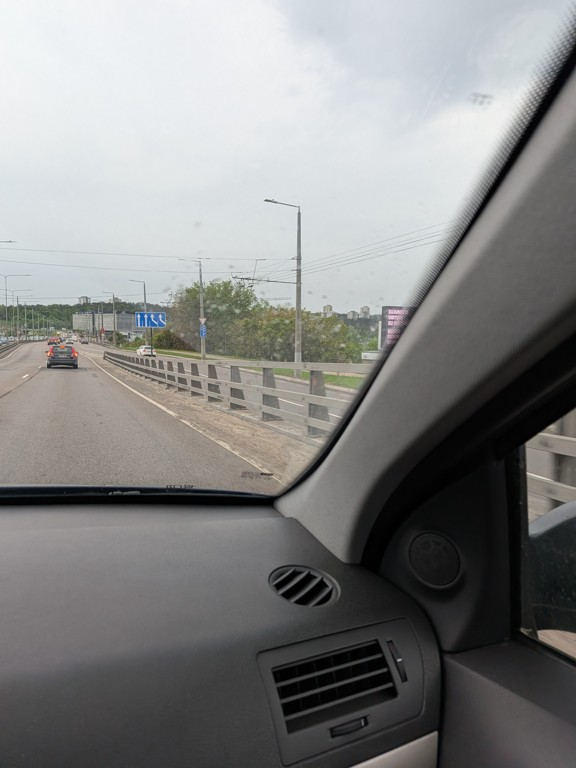

----------------------------------------------------------------------------------------------------
IMAGE: /content/drive/MyDrive/ML_Group/images_resized/image_00035.jpg
ORIGINAL: images/Messenger_creation_27C44FE6-1E04-4E9B-BEEF-A37F71BC908D.jpeg
CAPTION: Nuotraukoje matoma miesto gatvė prie kelio darbų zonos. Matomi laikini raudonai balti atitvarai ir pravažiuojantis raudonas autobusas. Aiškaus įskaitomo kelio ženklo teksto nėra.


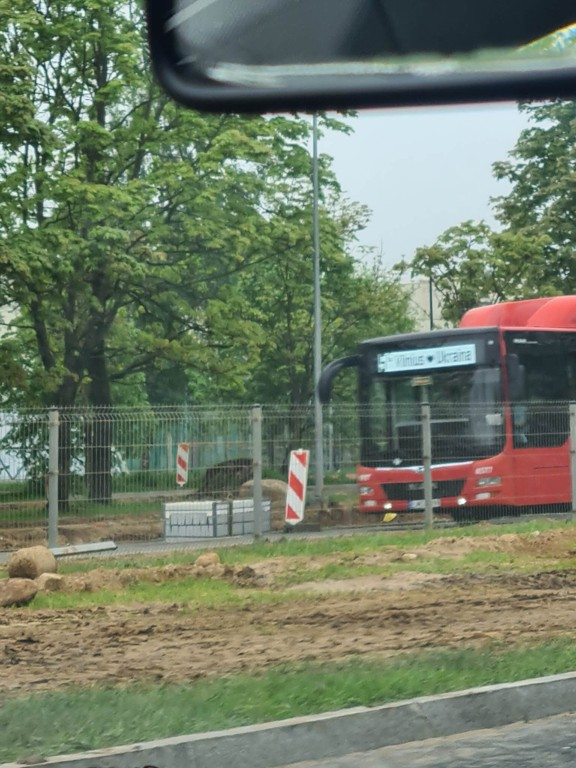

----------------------------------------------------------------------------------------------------
IMAGE: /content/drive/MyDrive/ML_Group/images_resized/image_00042.jpg
ORIGINAL: images/Messenger_creation_72A524CA-6615-440D-AC7F-5794CAF41874.jpeg
CAPTION: Nuotraukoje matoma miesto gatvė šalia modernaus stiklinio pastato. Prie pastato matomas pėsčiųjų perėjos ženklas, nurodantis perėją per gatvę. Įskaitomo teksto ant kelio ženklo nėra.


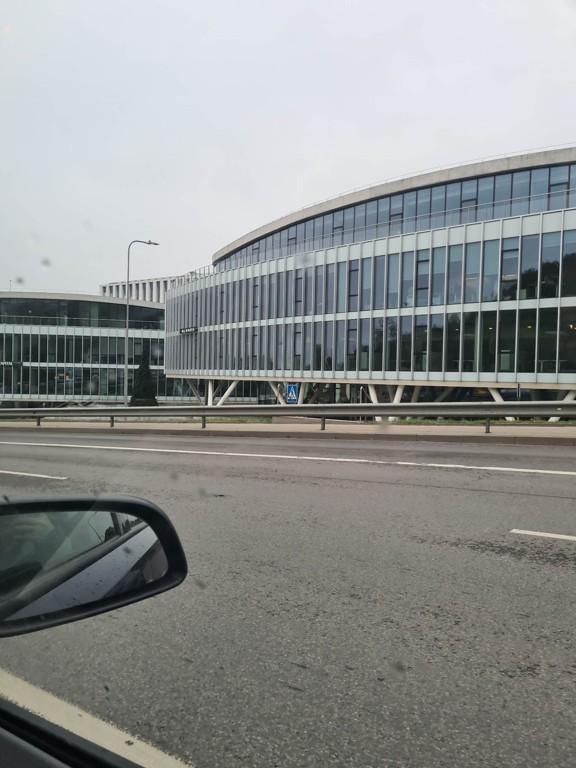

----------------------------------------------------------------------------------------------------
IMAGE: /content/drive/MyDrive/ML_Group/images_resized/image_00047.jpg
ORIGINAL: images/Messenger_creation_939ADD21-8A22-4325-A850-18DE0B1A314C.jpeg
CAPTION: Nuotraukoje matoma miesto gatvė prie viaduko ir viešojo transporto stotelės. Dešinėje matomi mėlyni informaciniai ženklai su simboliais ir užrašu „100 m“, nurodantys objektus ar paslaugas už nurodyto atstumo. Taip pat matomas autobusų stotelės ženklas.


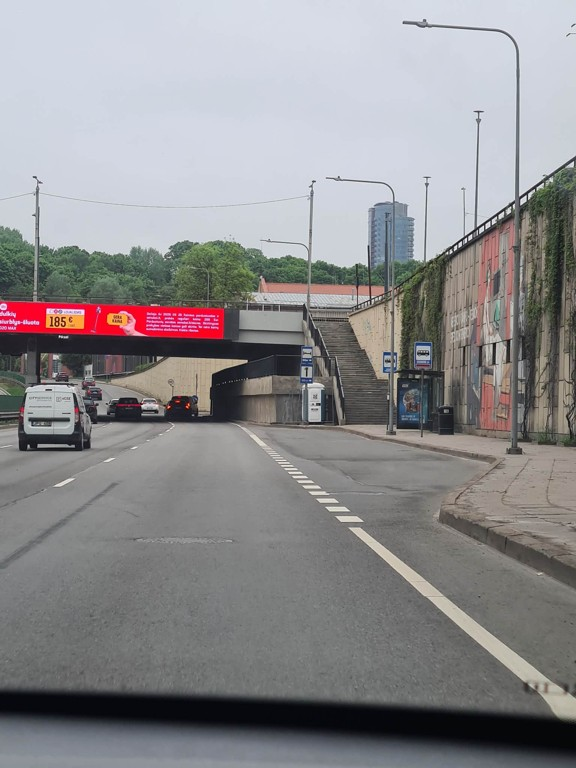

----------------------------------------------------------------------------------------------------


In [12]:
import random
from IPython.display import display
from PIL import Image

samples = random.sample(dataset, 5)

for sample in samples:
    print("IMAGE:", sample["image"])
    print("ORIGINAL:", sample["original_image"])
    print("CAPTION:", sample["caption_lt"])
    display(Image.open(sample["image"]))
    print("-" * 100)

To format the dataset, all vision fine-tuning tasks should follow this format:

```python
[
    {
        "role": "user",
        "content": [
            {"type": "text", "text": instruction},
            {"type": "image", "image": sample["image"]},
        ],
    },
    {
        "role": "user",
        "content": [
            {"type": "text", "text": instruction},
            {"type": "image", "image": sample["image"]},
        ],
    },
]
```

In [ ]:
from unsloth import get_chat_template

processor = get_chat_template(
    processor,
    "gemma-3"
)

In [ ]:
from unsloth import FastVisionModel
from transformers import TextStreamer
import torch

FastVisionModel.for_inference(model)

sample = test_data[0]
image = sample["messages"][0]["content"][1]["image"]

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": instruction},
        ],
    }
]

input_text = processor.apply_chat_template(
    messages,
    add_generation_prompt=True
)

inputs = processor(
    image,
    input_text,
    add_special_tokens=False,
    return_tensors="pt",
).to("cuda")

print("REFERENCE CAPTION:")
print(sample["caption_lt"])

print("\nMODEL OUTPUT BEFORE FINE-TUNING:\n")

text_streamer = TextStreamer(processor.tokenizer, skip_prompt=True)

with torch.inference_mode():
    _ = model.generate(
        **inputs,
        streamer=text_streamer,
        max_new_tokens=120,
        use_cache=True,
        do_sample=False,
    )

del inputs
torch.cuda.empty_cache()

<a name="Train"></a>
### Train the model
Now let's train our model. We do 60 steps to speed things up, but you can set `num_train_epochs=1` for a full run, and turn off `max_steps=None`. We also support `DPOTrainer` and `GRPOTrainer` for reinforcement learning!!

We use our new `UnslothVisionDataCollator` which will help in our vision finetuning setup.

In [ ]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model)

trainer = SFTTrainer(
    model = model,
    train_dataset = train_data,
    eval_dataset = val_data,
    processing_class = processor.tokenizer,
    data_collator = UnslothVisionDataCollator(model, processor),
    args = SFTConfig(
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 4,
        gradient_checkpointing = True,
        gradient_checkpointing_kwargs = {"use_reentrant": False},
        max_grad_norm = 0.3,
        warmup_ratio = 0.03,

        max_steps = 60,

        learning_rate = 2e-4,
        logging_steps = 1,
        save_strategy = "steps",
        optim = "adamw_torch_fused",
        weight_decay = 0.001,
        lr_scheduler_type = "cosine",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",

        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
    )
)

Unsloth: Switching to float32 training since model cannot work with float16

In [ ]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.741 GB.
5.416 GB of memory reserved.


In [ ]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 68,686 | Num Epochs = 1 | Total steps = 30
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 38,497,792/4,000,000,000 (0.96% trained)
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss
1,2.479900
2,3.098400
3,2.089700
4,2.224700
5,1.667500
6,1.509600
7,0.855900
8,0.664800
9,0.566600
10,0.221500


In [ ]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

760.6053 seconds used for training.
12.68 minutes used for training.
Peak reserved memory = 6.061 GB.
Peak reserved memory for training = 0.645 GB.
Peak reserved memory % of max memory = 41.117 %.
Peak reserved memory for training % of max memory = 4.376 %.


<a name="Inference"></a>
### Inference
Let's run the model! You can modify the instruction and input—just leave the output blank.

We'll use the best hyperparameters for inference on Gemma: `top_p=0.95`, `top_k=64`, and `temperature=1.0`.

In [ ]:
FastVisionModel.for_inference(model)

sample = test_data[0]
image = sample["messages"][0]["content"][1]["image"]

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": instruction},
        ],
    }
]

input_text = processor.apply_chat_template(
    messages,
    add_generation_prompt=True
)

inputs = processor(
    image,
    input_text,
    add_special_tokens=False,
    return_tensors="pt",
).to("cuda")

print("REFERENCE CAPTION:")
print(sample["caption_lt"])

print("\nMODEL OUTPUT AFTER FINE-TUNING:\n")

text_streamer = TextStreamer(processor.tokenizer, skip_prompt=True)

with torch.inference_mode():
    _ = model.generate(
        **inputs,
        streamer=text_streamer,
        max_new_tokens=120,
        use_cache=True,
        do_sample=False,
    )

del inputs
torch.cuda.empty_cache()

[
\left( { B _ { n } ^ { + } , { q } _ { 2 } , { k } _ { 2 } ^ { + } \right)
[
\left. { { q } _ { 2 } , k _ { 2 } ^ { + } { k } _ { 2 } ^ { + } , { q } _ { 2 } ^ { + } } \right]
= n B _ { n } ^ { + } , { q _ { 2 } }
image<end_of_turn>

<a name="Save"></a>
### Saving, loading finetuned models
To save the final model as LoRA adapters, use Hugging Face’s `push_to_hub` for online saving, or `save_pretrained` for local storage.

**[NOTE]** This ONLY saves the LoRA adapters, and not the full model. To save to 16bit or GGUF, scroll down!

In [ ]:
save_dir = "/content/drive/MyDrive/ML_Group/gemma_3_road_signs_lora"

model.save_pretrained(save_dir)
processor.save_pretrained(save_dir)

print("Saved to:", save_dir)

['lora_model/processor_config.json']